# 02b · K-Means Clustering — Theory & Implementation from Scratch

> **DS100 — Data Science Masterclass**  
> *Wear the hat of a technical expert **and** an intuitive teacher.*

---

## Road map

```
Part 0 — Intuition           (what problem K-Means solves)
Part 1 — Mathematics         (objective function, assignment, update)
Part 2 — Algorithm           (the two-step loop + convergence proof sketch)
Part 3 — Implementation      (from first principles — loops only)
Part 4 — Visualisation       (step-by-step iteration snapshots)
Part 5 — Choosing K          (elbow method — inertia vs k)
Part 6 — Limitations         (when K-Means fails)
```

**Rule**: the K-Means algorithm uses only Python loops + NumPy — no scikit-learn for the core logic.

---
## Part 0 — Intuition

**The analogy**: imagine you run a pizza chain and want to open exactly $K$ stores to minimise total customer travel distance.  
You don't know which $K$ locations are best — but if you already knew which customers belonged to each store, you'd put the store at the **centroid** (average location) of those customers.  
And if you already knew the store locations, you'd assign each customer to the **nearest** store.  

K-Means alternates between these two obvious steps until neither changes anything — that's it.

### What K-Means produces

- $K$ **centroids** $\mu_1, \ldots, \mu_K \in \mathbb{R}^d$
- A **label** $c^{(i)} \in \{1, \ldots, K\}$ for every point $\mathbf{x}^{(i)}$
- The partition minimises **within-cluster spread** (defined precisely in Part 1)

### When to use it

| Good fit | Poor fit |
|----------|----------|
| Roughly spherical, similar-sized clusters | Non-convex shapes (rings, crescents) |
| $n$ in the millions (scales well) | Clusters of very different densities |
| $K$ is known or can be estimated | Unknown $K$ with no elbow in inertia |
| Continuous, standardised features | Categorical data, high-dimensional sparse |

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch

mpl.rcParams.update({'font.size': 12, 'figure.dpi': 110})
np.random.seed(42)

print('Imports ready.')

Imports ready.


---
## Part 1 — Mathematics

### 1.1 Objective function — Within-Cluster Sum of Squares (WCSS)

Given $n$ points $\{\mathbf{x}^{(1)}, \ldots, \mathbf{x}^{(n)}\}$ and $K$ clusters, define:

$$
J = \sum_{k=1}^{K} \sum_{i \,:\, c^{(i)}=k} \left\| \mathbf{x}^{(i)} - \boldsymbol{\mu}_k \right\|^2
$$

where $\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{i \in C_k} \mathbf{x}^{(i)}$ is the **centroid** of cluster $k$.

$J$ is called **inertia** in scikit-learn.  
K-Means seeks to minimise $J$ over both the assignments $c^{(i)}$ and the centroids $\boldsymbol{\mu}_k$.

> **Why squared distance?** Same reason as in linear regression — penalises large deviations more, and the minimum of the squared loss w.r.t. the mean has a clean closed form.

---

### 1.2 Assignment step (E-step)

Hold centroids fixed; assign each point to the nearest one:

$$
c^{(i)} = \arg\min_{k \in \{1,\ldots,K\}} \left\| \mathbf{x}^{(i)} - \boldsymbol{\mu}_k \right\|^2
$$

This can only **decrease** $J$ — reassigning $\mathbf{x}^{(i)}$ to a closer centroid reduces its contribution to the sum.

---

### 1.3 Update step (M-step)

Hold assignments fixed; move each centroid to the **mean** of its assigned points:

$$
\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{i \,:\, c^{(i)}=k} \mathbf{x}^{(i)}
$$

Why the mean? Because for a fixed set $C_k$, the value of $\boldsymbol{\mu}$ that minimises $\sum_{i \in C_k} \|\mathbf{x}^{(i)} - \boldsymbol{\mu}\|^2$ is exactly the sample mean:

$$
\frac{\partial}{\partial \boldsymbol{\mu}} \sum_{i \in C_k} \|\mathbf{x}^{(i)} - \boldsymbol{\mu}\|^2
= -2 \sum_{i \in C_k} (\mathbf{x}^{(i)} - \boldsymbol{\mu}) = \mathbf{0}
\implies \boldsymbol{\mu} = \frac{1}{|C_k|}\sum_{i \in C_k} \mathbf{x}^{(i)}
$$

The update step also cannot increase $J$.

---

### 1.4 Convergence guarantee

Since:
1. $J \geq 0$ (bounded below), and  
2. Each step can only **decrease or leave unchanged** $J$,

the algorithm must converge — **but only to a local minimum**, not necessarily the global one.

The global minimum is NP-hard to find in general, so in practice we run K-Means multiple times with different random initialisations and keep the best result.

---

### 1.5 Complexity per iteration

| Step | Time | Space |
|------|------|-------|
| Assignment | $O(nKd)$ | $O(n)$ labels |
| Update | $O(nd)$ | $O(Kd)$ centroids |

K-Means scales very well — linear in $n$ and $d$.  
For $n = 10^6$, $K = 100$, $d = 50$: roughly $5 \times 10^9$ FLOPs per iteration — fast on modern hardware.

---
## Part 2 — Algorithm

```
Input:  data X (n × d),  number of clusters K,  max iterations T

1. Initialise K centroids  μ₁, ..., μ_K  (random points or K-Means++)

2. Repeat until convergence (or T iterations):

   Assignment step:
       For each point x⁽ⁱ⁾:
           c⁽ⁱ⁾ ← argmin_k  ‖x⁽ⁱ⁾ − μ_k‖²

   Update step:
       For each cluster k:
           μ_k ← mean of all x⁽ⁱ⁾ with c⁽ⁱ⁾ = k

   Convergence check:
       If no centroid moved by more than ε → stop

Output:  centroids μ₁…μ_K,  labels c⁽¹⁾…c⁽ⁿ⁾
```

### K-Means++ initialisation

Random initialisation can lead to very bad local minima.  
K-Means++ improves the starting centroids:

1. Choose first centroid uniformly at random.
2. For each subsequent centroid: sample a point with probability **proportional to its squared distance from the nearest already-chosen centroid**.
3. Points far from existing centroids are more likely to be chosen → better spread.

K-Means++ gives an $O(\log K)$ approximation guarantee in expectation.

In [2]:
# ============================================================
# Core building blocks — pure Python / NumPy, no sklearn
# ============================================================

def sq_euclidean(p, q):
    """Squared Euclidean distance between two 1-D arrays."""
    diff = p - q
    return float(np.dot(diff, diff))


def assign_clusters(X, centroids):
    """Assign each point in X to the nearest centroid.
    Returns integer label array of shape (n,).
    """
    n = len(X)
    K = len(centroids)
    labels = np.zeros(n, dtype=int)
    for i in range(n):
        best_dist = float('inf')
        best_k    = 0
        for k in range(K):
            d = sq_euclidean(X[i], centroids[k])
            if d < best_dist:
                best_dist = d
                best_k    = k
        labels[i] = best_k
    return labels


def update_centroids(X, labels, K):
    """Move each centroid to the mean of its assigned points."""
    d          = X.shape[1]
    centroids  = np.zeros((K, d))
    for k in range(K):
        members = X[labels == k]
        if len(members) > 0:
            # Mean — derived earlier: minimises sum of squared distances
            for dim in range(d):
                total = 0.0
                for xi in members:
                    total += xi[dim]
                centroids[k, dim] = total / len(members)
    return centroids


def kmeans_plus_plus_init(X, K, rng):
    """K-Means++ centroid initialisation.
    Each centroid is sampled with probability ∝ (distance to nearest chosen centroid)².
    """
    n = len(X)
    chosen = [int(rng.integers(0, n))]       # first centroid: uniform random

    for _ in range(K - 1):
        # For each point: squared distance to nearest already-chosen centroid
        dists = np.array([
            min(sq_euclidean(X[i], X[c]) for c in chosen)
            for i in range(n)
        ])
        probs = dists / dists.sum()           # normalise → probability distribution
        next_idx = int(rng.choice(n, p=probs))
        chosen.append(next_idx)

    return X[np.array(chosen)].copy()

print('Core functions defined.')

Core functions defined.


In [3]:
# ============================================================
# KMeans class — from first principles
# ============================================================

class KMeans:
    """
    K-Means clustering from scratch.

    Parameters
    ----------
    K        : number of clusters
    max_iter : maximum number of E-M iterations
    tol      : convergence threshold (max centroid shift)
    init     : 'kmeans++' (default) or 'random'
    n_init   : number of re-runs; keep the one with lowest inertia
    """

    def __init__(self, K, max_iter=300, tol=1e-6, init='kmeans++', n_init=10):
        self.K        = K
        self.max_iter = max_iter
        self.tol      = tol
        self.init     = init
        self.n_init   = n_init
        # Fitted attributes
        self.centroids_  = None
        self.labels_     = None
        self.inertia_    = None
        self.n_iter_     = None
        self.history_    = []   # (centroids, labels) snapshot per iteration

    # ----------------------------------------------------------
    def _compute_inertia(self, X, labels, centroids):
        total = 0.0
        for i in range(len(X)):
            total += sq_euclidean(X[i], centroids[labels[i]])
        return total

    # ----------------------------------------------------------
    def _fit_once(self, X, rng):
        """Run one full K-Means trial; return (centroids, labels, inertia, n_iter, history)."""
        if self.init == 'kmeans++':
            centroids = kmeans_plus_plus_init(X, self.K, rng)
        else:
            idx = rng.choice(len(X), size=self.K, replace=False)
            centroids = X[idx].copy()

        history = []

        for it in range(self.max_iter):
            labels    = assign_clusters(X, centroids)
            history.append((centroids.copy(), labels.copy()))

            new_centroids = update_centroids(X, labels, self.K)

            # Convergence: check max shift across all centroids
            max_shift = max(
                math.sqrt(sq_euclidean(new_centroids[k], centroids[k]))
                for k in range(self.K)
            )
            centroids = new_centroids

            if max_shift < self.tol:
                break

        inertia = self._compute_inertia(X, labels, centroids)
        return centroids, labels, inertia, it + 1, history

    # ----------------------------------------------------------
    def fit(self, X, random_state=0):
        rng = np.random.default_rng(random_state)
        best_inertia = float('inf')

        for run in range(self.n_init):
            centroids, labels, inertia, n_iter, history = self._fit_once(X, rng)
            if inertia < best_inertia:
                best_inertia = inertia
                self.centroids_ = centroids
                self.labels_    = labels
                self.inertia_   = inertia
                self.n_iter_    = n_iter
                self.history_   = history

        return self

    # ----------------------------------------------------------
    def predict(self, X):
        return assign_clusters(X, self.centroids_)

print('KMeans class ready.')

KMeans class ready.


In [4]:
# ============================================================
# Generate dataset (3 Gaussian blobs, no sklearn)
# ============================================================

rng = np.random.default_rng(7)

centres   = np.array([[0.0, 0.0], [6.0, 1.0], [3.0, 6.0]])
std       = 0.9
n_per     = 40

X = np.vstack([
    rng.normal(loc=c, scale=std, size=(n_per, 2))
    for c in centres
])
true_labels = np.repeat([0, 1, 2], n_per)

print(f'Dataset: {len(X)} points  |  3 true clusters')

Dataset: 120 points  |  3 true clusters


---
## Part 3 — Fitting and Step-by-Step Visualisation

We capture a snapshot `(centroids, labels)` after every iteration and plot the first six to watch the algorithm converge.

In [5]:
# ============================================================
# Fit K-Means and inspect the iteration history
# ============================================================

km = KMeans(K=3, max_iter=20, n_init=1, init='kmeans++').fit(X, random_state=3)

print(f'Converged in {km.n_iter_} iterations')
print(f'Final inertia: {km.inertia_:.2f}')
print(f'Centroids:\n{np.round(km.centroids_, 3)}')
print(f'\nTrue centres:\n{centres}')

Converged in 2 iterations
Final inertia: 156.22
Centroids:
[[ 2.945  5.861]
 [-0.197 -0.121]
 [ 5.867  0.842]]

True centres:
[[0. 0.]
 [6. 1.]
 [3. 6.]]


C:\Users\shrip\AppData\Local\Temp\ipykernel_73776\4176620178.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP   = plt.cm.get_cmap('tab10', 3)


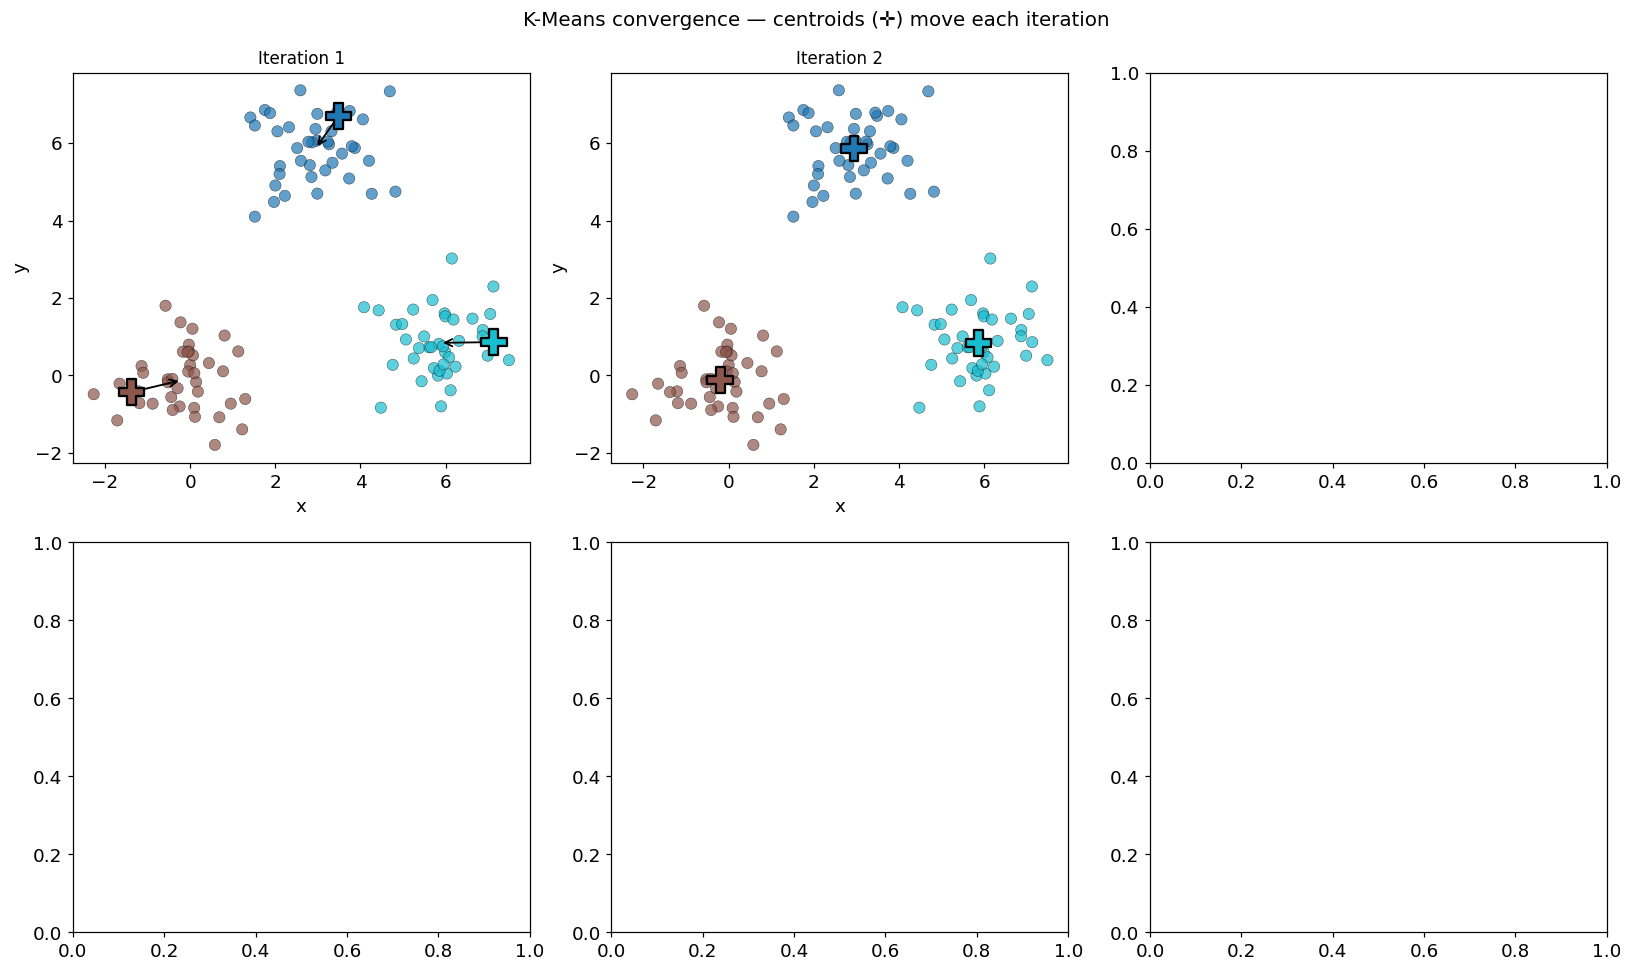

In [6]:
# ============================================================
# Step-by-step iteration grid
# ============================================================

CMAP   = plt.cm.get_cmap('tab10', 3)
MARKER = 'P'   # filled plus = centroid

n_show = min(6, len(km.history_))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for idx in range(n_show):
    centroids_i, labels_i = km.history_[idx]
    ax = axes[idx]

    ax.scatter(X[:, 0], X[:, 1], c=labels_i, cmap=CMAP, alpha=0.7,
               edgecolors='k', lw=0.3, s=55, vmin=0, vmax=2)
    ax.scatter(centroids_i[:, 0], centroids_i[:, 1],
               c=range(km.K), cmap=CMAP, marker=MARKER, s=280,
               edgecolors='k', lw=1.5, zorder=5, vmin=0, vmax=2)
    ax.set_title(f'Iteration {idx + 1}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    # Draw arrows showing centroid movement to next iteration
    if idx + 1 < n_show:
        centroids_next, _ = km.history_[idx + 1]
        for k in range(km.K):
            dx = centroids_next[k, 0] - centroids_i[k, 0]
            dy = centroids_next[k, 1] - centroids_i[k, 1]
            if dx**2 + dy**2 > 1e-6:
                ax.annotate('', xy=(centroids_next[k,0], centroids_next[k,1]),
                            xytext=(centroids_i[k,0], centroids_i[k,1]),
                            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

plt.suptitle('K-Means convergence — centroids (✛) move each iteration', fontsize=13)
plt.tight_layout()
plt.show()

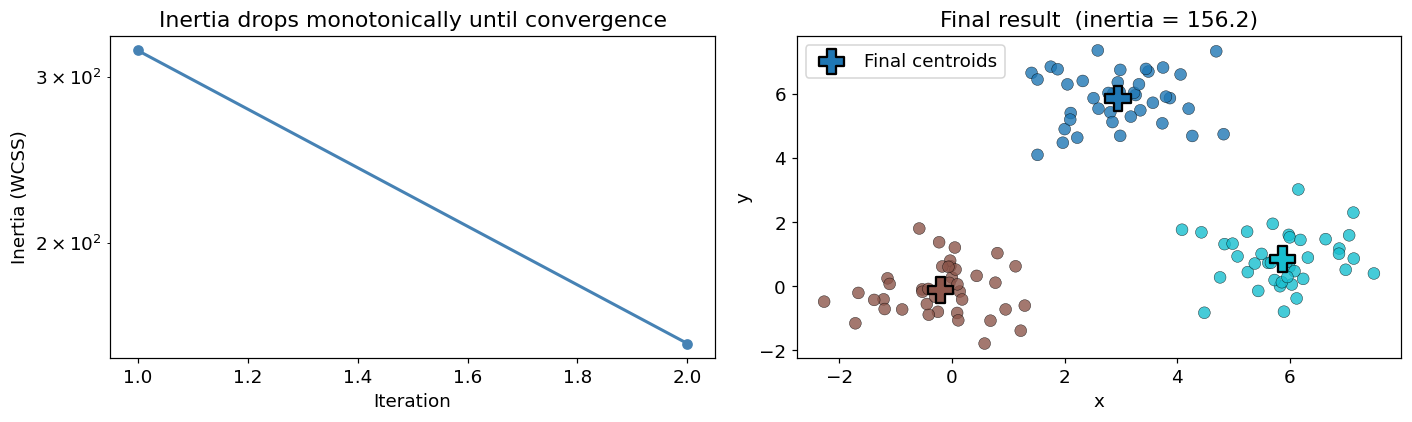

In [7]:
# ============================================================
# Inertia over iterations (convergence curve)
# ============================================================

inertias_per_iter = [
    km._compute_inertia(X, labels_i, centroids_i)
    for centroids_i, labels_i in km.history_
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, len(inertias_per_iter) + 1), inertias_per_iter,
        'o-', color='steelblue', lw=2, ms=6)
ax.set_xlabel('Iteration')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Inertia drops monotonically until convergence')
ax.set_yscale('log')

# Final result
ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap=CMAP, alpha=0.8,
           edgecolors='k', lw=0.3, s=60, vmin=0, vmax=2)
ax.scatter(km.centroids_[:, 0], km.centroids_[:, 1],
           c=range(km.K), cmap=CMAP, marker=MARKER, s=280,
           edgecolors='k', lw=1.5, zorder=5, vmin=0, vmax=2,
           label='Final centroids')
ax.set_title(f'Final result  (inertia = {km.inertia_:.1f})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

plt.tight_layout(); plt.show()

---
## Part 4 — Multiple Runs (Beating Local Minima)

K-Means can converge to different local minima depending on the initial centroids.  
The standard remedy: run it $r$ times and keep the solution with the lowest inertia.

Below we run 5 times with random init and 5 times with K-Means++ init to see the difference.

In [8]:
# ============================================================
# Compare random init vs K-Means++ across 5 seeds
# ============================================================

n_runs  = 5
seeds   = list(range(n_runs))

random_inertias  = []
kpp_inertias     = []

for s in seeds:
    km_rand = KMeans(K=3, n_init=1, init='random').fit(X, random_state=s)
    km_kpp  = KMeans(K=3, n_init=1, init='kmeans++').fit(X, random_state=s)
    random_inertias.append(km_rand.inertia_)
    kpp_inertias.append(km_kpp.inertia_)

print(f'Random init   — inertias: {[round(v,1) for v in random_inertias]}')
print(f'K-Means++ init — inertias: {[round(v,1) for v in kpp_inertias]}')
print()
print(f'Random   std : {np.std(random_inertias):.2f}   (high variance = frequent bad local minima)')
print(f'KMeans++ std : {np.std(kpp_inertias):.2f}   (low variance = more consistent results)')

Random init   — inertias: [156.2, 156.2, 156.2, 156.2, 156.2]
K-Means++ init — inertias: [156.2, 156.2, 156.2, 156.2, 156.2]

Random   std : 0.00   (high variance = frequent bad local minima)
KMeans++ std : 0.00   (low variance = more consistent results)


---
## Part 5 — Choosing K: the Elbow Method

K-Means requires us to specify $K$ in advance.  
But how do we choose $K$?

### Elbow heuristic

Fit K-Means for $K = 1, 2, \ldots, K_{\max}$ and plot inertia vs $K$:

- Inertia always decreases as $K$ increases (more clusters = tighter fit).
- At the **true** $K$, the decrease typically becomes much smaller — forming an **elbow**.
- Choose the $K$ at the kink.

**Caveat**: the elbow is often subtle on real data. It is a heuristic, not a proof.  
Other approaches: Silhouette score, Gap statistic, BIC/AIC (for GMMs).

K=1  inertia=1717.1
K=2  inertia=830.7
K=3  inertia=156.2
K=4  inertia=135.4
K=5  inertia=117.0
K=6  inertia=102.3


K=7  inertia=83.6


K=8  inertia=71.5

Elbow detected at K = 6


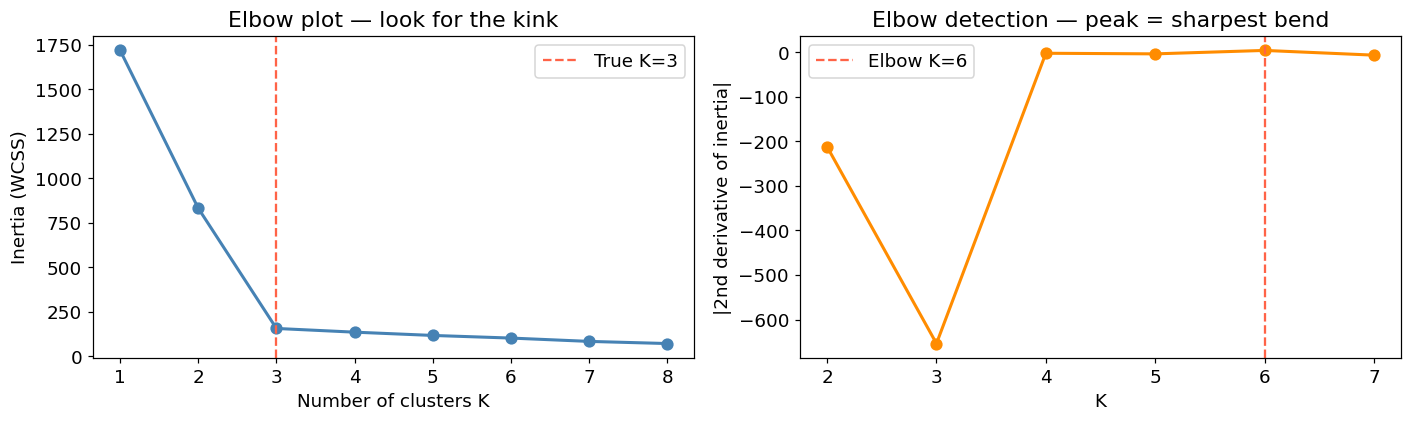

In [9]:
# ============================================================
# Elbow method — inertia vs K
# ============================================================

K_range  = range(1, 9)
inertias = []

for k in K_range:
    km_k = KMeans(K=k, n_init=5, init='kmeans++').fit(X, random_state=0)
    inertias.append(km_k.inertia_)
    print(f'K={k}  inertia={km_k.inertia_:.1f}')

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(list(K_range), inertias, 'o-', color='steelblue', lw=2, ms=7)
ax.axvline(3, color='tomato', ls='--', lw=1.5, label='True K=3')
ax.set_xlabel('Number of clusters K')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow plot — look for the kink')
ax.set_xticks(list(K_range))
ax.legend()

# Second derivative (rate-of-change of improvement) — sharpest drop = elbow
delta  = np.diff(inertias)        # first differences
delta2 = np.diff(delta)           # second differences (acceleration)
elbow_k = int(np.argmin(delta2)) + 2  # +2 because double-diff loses 2 points
print(f'\nElbow detected at K = {elbow_k}')

ax = axes[1]
ax.plot(list(K_range)[1:-1], -delta2, 'o-', color='darkorange', lw=2, ms=7)
ax.axvline(elbow_k, color='tomato', ls='--', lw=1.5, label=f'Elbow K={elbow_k}')
ax.set_xlabel('K')
ax.set_ylabel('|2nd derivative of inertia|')
ax.set_title('Elbow detection — peak = sharpest bend')
ax.set_xticks(list(K_range)[1:-1])
ax.legend()

plt.tight_layout(); plt.show()

---
## Part 6 — Limitations of K-Means

K-Means assumes clusters are:
1. **Spherical** (circular in 2D) — the Voronoi partition is defined by distance to centroids.
2. **Similar in size** — the centroid "attracts" roughly equal numbers of points.
3. **Non-overlapping** — hard assignments, no probabilistic membership.

Below we demonstrate two classic failure modes.

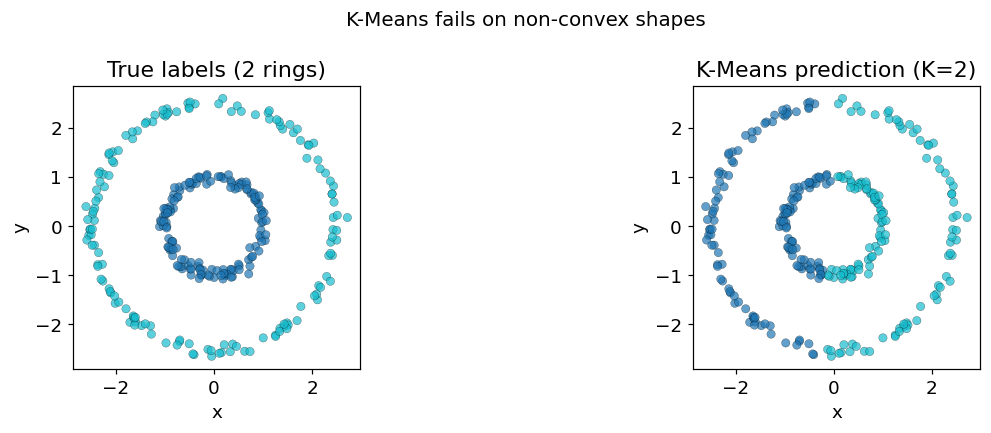

K-Means splits the rings horizontally/vertically — it cannot discover the ring structure.
DBSCAN (density-based) or spectral clustering handles this correctly.


In [10]:
# ============================================================
# Failure mode 1: Concentric rings  (non-convex shapes)
# ============================================================

rng2 = np.random.default_rng(42)
n_ring = 150

# Inner ring
angles_in  = rng2.uniform(0, 2 * math.pi, n_ring)
X_in = np.column_stack([np.cos(angles_in), np.sin(angles_in)])
X_in += rng2.normal(0, 0.07, X_in.shape)

# Outer ring
angles_out = rng2.uniform(0, 2 * math.pi, n_ring)
X_out = np.column_stack([2.5 * np.cos(angles_out), 2.5 * np.sin(angles_out)])
X_out += rng2.normal(0, 0.07, X_out.shape)

X_rings       = np.vstack([X_in, X_out])
true_rings    = np.array([0] * n_ring + [1] * n_ring)

km_rings = KMeans(K=2, n_init=5, init='kmeans++').fit(X_rings, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, title in [
    (axes[0], true_rings,       'True labels (2 rings)'),
    (axes[1], km_rings.labels_, 'K-Means prediction (K=2)'),
]:
    ax.scatter(X_rings[:, 0], X_rings[:, 1], c=labels, cmap='tab10',
               alpha=0.7, edgecolors='k', lw=0.2, s=30, vmin=0, vmax=1)
    ax.set_title(title); ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('K-Means fails on non-convex shapes', fontsize=13)
plt.tight_layout(); plt.show()

print('K-Means splits the rings horizontally/vertically — it cannot discover the ring structure.')
print('DBSCAN (density-based) or spectral clustering handles this correctly.')

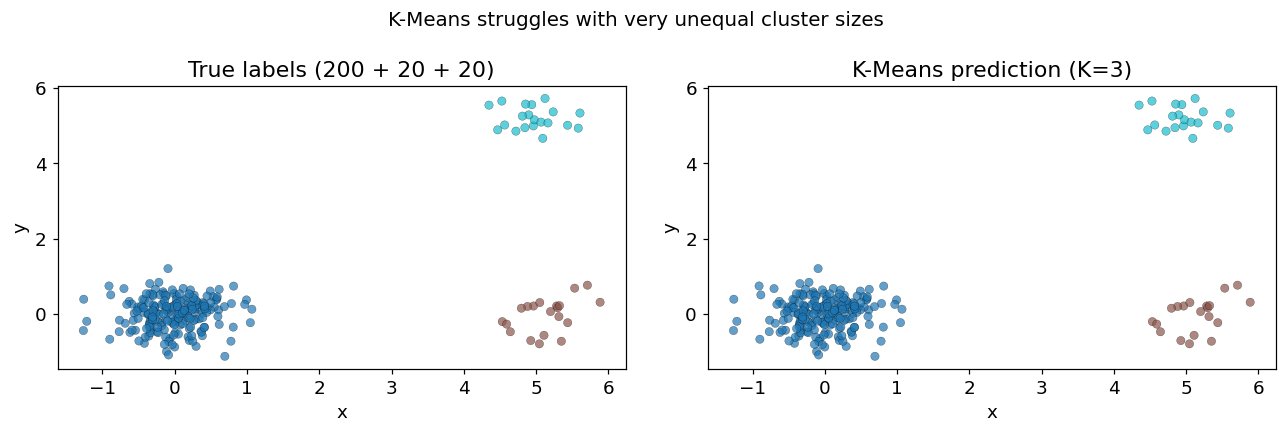

In [11]:
# ============================================================
# Failure mode 2: Very different cluster sizes
# ============================================================

rng3 = np.random.default_rng(99)
X_unbal = np.vstack([
    rng3.normal([0,  0], 0.4, (200, 2)),   # large cluster
    rng3.normal([5,  0], 0.4, ( 20, 2)),   # tiny cluster A
    rng3.normal([5,  5], 0.4, ( 20, 2)),   # tiny cluster B
])
true_unbal = np.array([0]*200 + [1]*20 + [2]*20)

km_unbal = KMeans(K=3, n_init=10, init='kmeans++').fit(X_unbal, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, title in [
    (axes[0], true_unbal,       'True labels (200 + 20 + 20)'),
    (axes[1], km_unbal.labels_, 'K-Means prediction (K=3)'),
]:
    ax.scatter(X_unbal[:, 0], X_unbal[:, 1], c=labels, cmap='tab10',
               alpha=0.7, edgecolors='k', lw=0.2, s=30, vmin=0, vmax=2)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('K-Means struggles with very unequal cluster sizes', fontsize=13)
plt.tight_layout(); plt.show()

In [12]:
# ============================================================
# Sanity-check: compare against sklearn on the clean 3-cluster data
# ============================================================

from sklearn.cluster import KMeans as SkKMeans

sk_km = SkKMeans(n_clusters=3, n_init=10, random_state=0).fit(X)

print(f'Our KMeans  inertia : {km.inertia_:.4f}')
print(f'sklearn     inertia : {sk_km.inertia_:.4f}')
print()
print('Centroids comparison (ours vs sklearn):')
print(f'{"Cluster":<10} {"Ours":>20} {"sklearn":>20}')
print('-' * 52)
# Match up clusters by nearest centroid
for k in range(3):
    nearest = int(np.argmin([np.linalg.norm(km.centroids_[k] - sk_km.cluster_centers_[j])
                              for j in range(3)]))
    our_c = np.round(km.centroids_[k], 3)
    sk_c  = np.round(sk_km.cluster_centers_[nearest], 3)
    print(f'k={k}       ({our_c[0]:6.3f}, {our_c[1]:6.3f})   ({sk_c[0]:6.3f}, {sk_c[1]:6.3f})')

Our KMeans  inertia : 156.2235
sklearn     inertia : 156.2235

Centroids comparison (ours vs sklearn):
Cluster                    Ours              sklearn
----------------------------------------------------
k=0       ( 2.945,  5.861)   ( 2.945,  5.861)
k=1       (-0.197, -0.121)   (-0.197, -0.121)
k=2       ( 5.867,  0.842)   ( 5.867,  0.842)


---
## Summary

### What we built from scratch

| Component | Description |
|-----------|-------------|
| `sq_euclidean(p, q)` | Squared Euclidean distance — one dot product |
| `assign_clusters(X, centroids)` | E-step: assign each point to its nearest centroid |
| `update_centroids(X, labels, K)` | M-step: move each centroid to the mean of its members |
| `kmeans_plus_plus_init(X, K, rng)` | Smart init: spread centroids by distance² sampling |
| `KMeans` | Full class with multiple restarts, convergence check, iteration history |

### Key formulas

$$
\underbrace{J = \sum_{k=1}^{K} \sum_{i \in C_k} \|\mathbf{x}^{(i)} - \boldsymbol{\mu}_k\|^2}_{\text{objective (WCSS / inertia)}}
\qquad
\underbrace{c^{(i)} = \arg\min_k \|\mathbf{x}^{(i)} - \boldsymbol{\mu}_k\|^2}_{\text{E-step (assignment)}}
\qquad
\underbrace{\boldsymbol{\mu}_k = \frac{1}{|C_k|}\sum_{i \in C_k}\mathbf{x}^{(i)}}_{\text{M-step (update)}}
$$

### K-Means vs Hierarchical Clustering

| | K-Means | Hierarchical |
|--|---------|-------------|
| Need to specify $K$? | Yes (use elbow / silhouette) | No (cut dendrogram after) |
| Complexity | $O(nKd)$ per iter — scales to millions | $O(n^3)$ naive — up to ~5k points |
| Deterministic? | No (random init) — use multiple restarts | Yes |
| Cluster shapes | Spherical (Voronoi cells) | Any (controlled by linkage) |
| Reassign points? | Yes — every iteration | No — merges are irreversible |

---
*DS100 · Built from first principles · Python loops + NumPy only*